### Spatial Regression Modeling in Python

This notebook demostrates how to fit various regression models using python.

- Linear Regression
- Spatial Error Model
- Spatial Lag Model
- Comparison of the three models

In [1]:
import numpy as np
import pandas as pd

import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#pip install -q libpysal

In [3]:
#pip install -q splot

In [4]:
from libpysal.weights import Queen,KNN
from splot.esda import plot_moran
from esda.moran import Moran
import spreg

### Data
In this notebook, I will be using a sample of some houses in Seattle to demostrate how to model the property price using spatial regression models. In the data, each row is a house, and the dependent variable is `price`, and we will be using some predictors to predict the house price and understand the relationships.


In [5]:
file = 'https://raw.githubusercontent.com/Ziqi-Li/GIS5106/refs/heads/main/data/seattle_houses.geojson'

houses = gpd.read_file(file)

In [6]:
houses.head()

,Unnamed: 0,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view,age,UTM_X,UTM_Y,log_price,price,geometry
0,74,3.00,3230,8625,10,3,0,3,17,544833.861947,5.267792e+06,6.100371,1260.0,POINT (5.45e+05 5.27e+06)
1,14667,2.50,2020,5501,7,3,0,0,5,564023.872203,5.260380e+06,5.618048,415.0,POINT (5.64e+05 5.26e+06)
2,2862,2.00,1340,3000,7,5,0,0,110,548855.802031,5.281573e+06,5.739572,549.0,POINT (5.49e+05 5.28e+06)
3,11095,3.75,3570,10125,10,3,0,0,1,558447.336282,5.268124e+06,6.204120,1600.0,POINT (5.58e+05 5.27e+06)
4,14791,2.00,1760,9055,7,4,0,0,30,565481.547734,5.278147e+06,5.662758,460.0,POINT (5.65e+05 5.28e+06)


Select the variables to be used in this exercise, I picked 5 predictors from the list.

In [7]:
variable_names = ['bathrooms', 'sqft_living', 'grade',
                  'condition', 'age']


y = houses[['price']].values

X = houses[variable_names].values

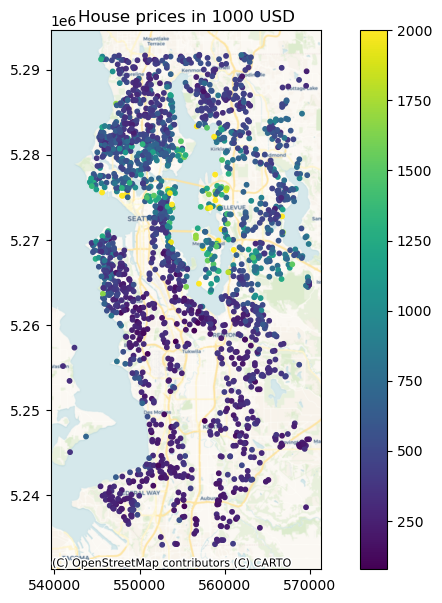

In [8]:
import contextily as cx

fig, ax = plt.subplots(1, 1,figsize=(10,7),dpi=100)

houses.plot(ax=ax, column='price',s=10, legend=True,vmax=2000) # >2000 k = 2M dollars as the lightest color

ax.set_title("House prices in 1000 USD")

cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager, crs=houses.crs,zoom=11)

### OLS model (baseline)

In [9]:
import statsmodels.formula.api as smf

model = smf.ols(
    formula='price ~ bathrooms + sqft_living + grade + condition + age',
    data=houses
)

results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     633.4
Date:                Mon, 26 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:45:14   Log-Likelihood:                -13632.
No. Observations:                2000   AIC:                         2.728e+04
Df Residuals:                    1994   BIC:                         2.731e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -1352.8587     55.391    -24.424      

### Results
Goodness of Fit:
R² = 0.614
The model explains 61.4% of the variation in house prices.


Coefficient Interpretation:


All interpretations are ceteris paribus (holding other variables constant).

- Intercept (-1352.86) p-value < 0.05 -> Baseline price when all variates are zero

- Bathrooms (46.28) p-value < 0.05 -> Each additional bathroom increases price by 46.28k USD

- Sqft_living (0.15) p-value < 0.05 -> Each additional square foot increases price by 0.15k USD

- Grade (165.78) p-value < 0.05 -> One-unit increase in grade raises price by 165.78 USD

- Condition (15.65) p-value < 0.05 -> Each one-unit increase in condition raises price by 15.65k USD

- Age (4.11) p-value < 0.05 -> Older houses are more expensive, conditional on other factors

All variables are statistically significant if using 0.05 as the p-value threshold.

Here I demostrate how to use `spreg` to fit a linear regression model as an alternative to `statsmodels`.

In [10]:
#In the spreg.OLS() you need to specify the y and X, also variable names (optional)

lr = spreg.OLS(y, X, name_y='price', name_x=variable_names)

In [11]:
print(lr.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :       price                Number of Observations:        2000
Mean dependent var  :    536.6610                Number of Variables   :           6
S.D. dependent var  :    355.2636                Degrees of Freedom    :        1994
R-squared           :      0.6136
Adjusted R-squared  :      0.6127
Sum squared residual: 9.74803e+07                F-statistic           :    633.3734
Sigma-square        :   48886.792                Prob(F-statistic)     :           0
S.E. of regression  :     221.104                Log likelihood        :  -13632.135
Sigma-square ML     :   48740.132                Akaike info criterion :   27276.270
S.E of regression ML:    220.7717                Schwarz criterion     :   27309.876

------------------------------------------------------------

Check out the OLS residuals map.

Use `ols.u` to get the residuals from the linear regression model.

In [12]:
lr.u

array([[ 228.83908036],
       [ 129.91077341],
       [ -76.59867771],
       ...,
       [-131.44660286],
       [ -60.10669082],
       [-229.91529109]])

We can plot the residuals. Again the residulas are the prediction errors.

<Axes: >

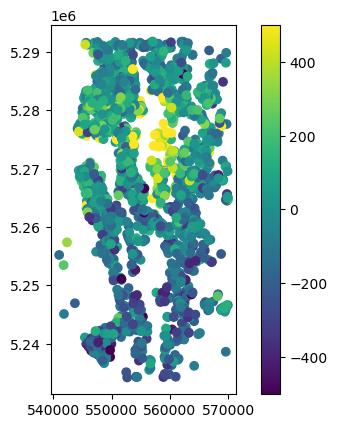

In [13]:
from matplotlib import colors

houses.plot(lr.u.reshape(-1), legend=True,vmin=-500, vmax=500)

From the OLS residuals map, we can see that there is a strong degree of spatial autocorrelation that high/low residuals are clustered. This is an  indication that we are missing the spatial structure in our model as well as violating the independence assumption of OLS.

Then lets assess the spatial autocorrelation more quantitatively through the calculating of the Moran's I on the residuals.

In [14]:
#Here we use the KNN contiguity
#For polygon, it is often Queen, for individual locations, its is often KNN
w = KNN.from_dataframe(houses, k=8)

#row standardization
w.transform = 'R'


/Users/ziqili/anaconda3/lib/python3.11/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


/Users/ziqili/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.37', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (0.37)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

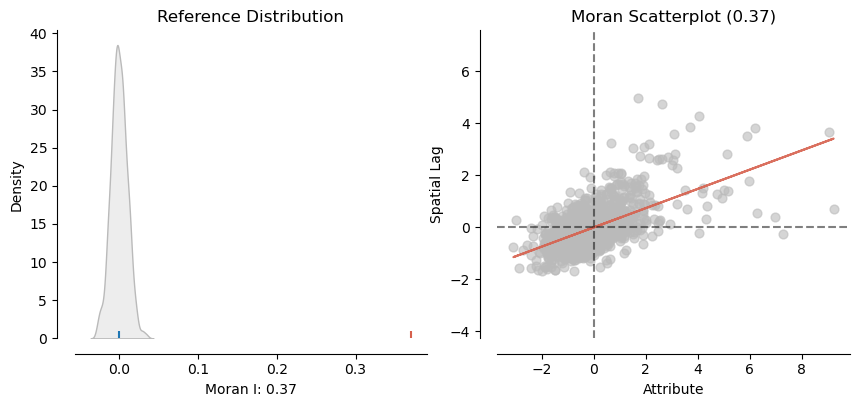

In [15]:
#Here, lets calculate the Moran's I value, and plot it.
#ols.u is the residuals from the OLS model

lm_moran = Moran(lr.u, w, permutations = 999) #999 permutations

plot_moran(lm_moran, figsize=(10,4))

We find that the Moran's I value equals 0.37 and it is far off the reference distribution, this reassures us that there is indeed a strong spatial pattern on the Linear regression model's residuals map.



Now there are two "spatial regression" choices:  we can use a **lag model**, or we can use an **error model**.
- If choosing a **lag model**, the underlying assumption is that you would assume  a house's price is influenced by nearby houses'price.
- If choosing a **error model**, the underlying assumption is that there is some un-measured/not included spatial context that influences a house's price, some examples may be school district, amenities, etc.


One convenience is that if you pass the weight matrix `w` to the OLS function, and also specify the `spat_diag=True`, then you get some additional spatial diagnostics (e.g., LM test) that can help you to decide. This also includes the Moran's I of the residuals if you specify `moran=True`.

In [16]:
ols = spreg.OLS(y, X, w=w, spat_diag=True, moran=True,
                name_y='price', name_x=variable_names)

print(ols.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :       price                Number of Observations:        2000
Mean dependent var  :    536.6610                Number of Variables   :           6
S.D. dependent var  :    355.2636                Degrees of Freedom    :        1994
R-squared           :      0.6136
Adjusted R-squared  :      0.6127
Sum squared residual: 9.74803e+07                F-statistic           :    633.3734
Sigma-square        :   48886.792                Prob(F-statistic)     :           0
S.E. of regression  :     221.104                Log likelihood        :  -13632.135
Sigma-square ML     :   48740.132                Akaike info criterion :   27276.270
S.E of regression ML:    220.7717                Schwarz criterion     :   27309.876

------------------------------------------------------------

The section on `DIAGNOSTICS FOR SPATIAL DEPENDENCE`

tells us from the stats in the L-M Tests, and our decision tree on the slides, when comparing Robust LM stats, the error model's Robust LM is larger than the lag's, so we can expect that the error model is more approproate than the lag model (comparing robust score: 358.8 vs 220.4).

### Spatial Error Model (SEM)

Now let's fit a spatial error model using `spreg.ML_Error()` where you need to specify the y, X and the weight matrix w.

In [17]:
sem = spreg.ML_Error(y, X, w=w, name_x=variable_names, name_y='price')

print(sem.summary)

/Users/ziqili/anaconda3/lib/python3.11/site-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
---------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :       price                Number of Observations:        2000
Mean dependent var  :    536.6610                Number of Variables   :           6
S.D. dependent var  :    355.2636                Degrees of Freedom    :        1994
Pseudo R-squared    :      0.5900
Log likelihood      : -13233.7086
Sigma-square ML     :  29786.0700                Akaike info criterion :   26479.417
S.E of regression   :    172.5864                Schwarz criterion     :   26513.023

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT      -717.58362    

The lambda (some other software or notation may use rho) coefficint for the spatially lagged error term is significant, and the magnitude is quite large (~0.75), this is suggesting that there is a strong spatial autocorrelation in the residuals which is captured in the lagged error term.


Note that the `sem.e_filtered` property of sem is supposed to be the iid (random) error. And the `sem.u` is the autoregressive error + the iid error. Now let's look at the moran's I of the residuals again.

In [18]:
sem.e_filtered

array([[245.67687078],
       [ 76.7901151 ],
       [-86.37381004],
       ...,
       [-35.33510227],
       [-62.77919443],
       [-62.45569119]])

/Users/ziqili/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: -0.02', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (-0.02)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

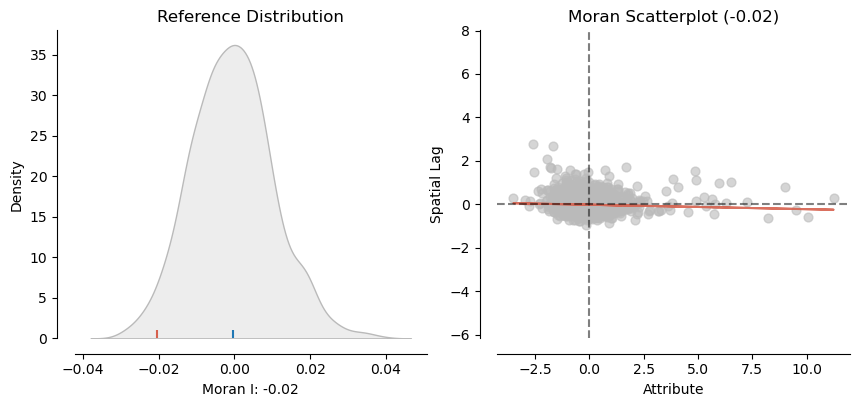

In [19]:
sem_moran = Moran(sem.e_filtered, w, permutations = 999) #999 permutations

plot_moran(sem_moran, zstandard=True, figsize=(10,4))

We find that the Moran's I value equals -0.02 and it is within the reference distribution, this indicates that the error model sucessfully removes the spatial context effect so the remaining is just some random noise.

### Spatial Lag Model

Though error model is preferred here, we can still fit a spatial lag model just for comparison.


In [20]:
slm = spreg.ML_Lag(y, X, w=w, name_y='price', name_x=variable_names)

print(slm.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :       price                Number of Observations:        2000
Mean dependent var  :    536.6610                Number of Variables   :           7
S.D. dependent var  :    355.2636                Degrees of Freedom    :        1993
Pseudo R-squared    :      0.7491
Spatial Pseudo R-squared:  0.6396
Log likelihood      : -13242.0290
Sigma-square ML     :  31672.9091                Akaike info criterion :   26498.058
S.E of regression   :    177.9688                Schwarz criterion     :   26537.264

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------------------------------------------------

The rho coefficint for the spatially lagged term `W_price ` is significant, and the magnitude is quite large (~0.54), this is suggesting that there is a strong spatial interaction effect for the dependent variable among nearby houses.

The direct and indirect effects measure a unit change of each variable will result in beta change in the y from the house itself (direct) and from nearby houses (indirect). Note that Total effect = Direct + Indirect 

/Users/ziqili/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.07', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (0.07)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

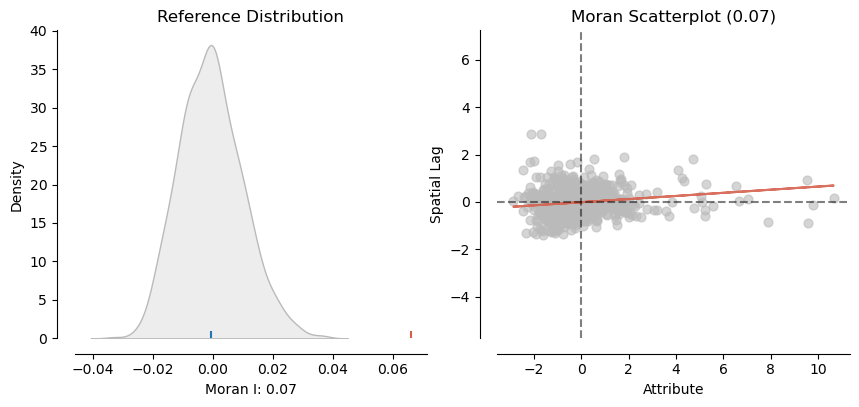

In [21]:
slm_moran = Moran(slm.u, w, permutations = 999) #999 permutations

plot_moran(slm_moran, zstandard=True, figsize=(10,4))

The residuals in the lag model also removes most of the spatial autocorrelation in the residuals (0.07) but it is still containing some level of of it.

### Cross-comparison of Lag, Error and OLS models.

Overall, we see the estimates are consistent despite of some changes. OLS model is not reliable because we know that the assumptions are violated. In the Lag model, even though we take account of the neighboring house prices , the residuals are still showing some weak autocorrelation. And in the error model, we do observe a bit more random residuals, so spatial context is important here.


| Predictor    | LR Estimates   | SLM Estimates   | SEM Estimates   |
| -----------  | ----------- | ----------- | ----------- |
| CONSTANT     | -1352.85*       | -997.11*        | -717.58*      |
| bathrooms    | 46.27*        | 35.15*        | 26.62*      |
| sqft_living    | 0.14*       | 0.14*       | 0.15*       |
| grade     | 165.77*       | 98.30*       | 100.94*       |
| condition     | 15.65*       | 8.67       | 14.67*       |
| age| 4.10*      | 2.35*      | 1.74*      
| lambda       | NA          | 0.54*       | 0.75*       |
|              |             |             |             |
| Moran's I of residuals    | 0.37        | 0.07        | -0.02       |

*p < 0.05